In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from darts import TimeSeries
from darts.models import RandomForestModel
from darts.metrics import mape, mae, mse
from darts.utils.model_selection import train_test_split
from darts.dataprocessing.transformers import Scaler, Diff
from darts.utils.missing_values import fill_missing_values
import warnings
import traceback

warnings.filterwarnings("ignore")

URLS = {
    "ihsg": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/ihsg.csv",
    "bi_rate": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/bi_interest_rate.csv",
    "cpi": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/cpi.csv",
    "m2": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/m2.csv",
    "npl_ratio": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/npl_ratio.csv",
    "npl": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/npl.csv",
    "usdidr": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/usd_idr.csv",
    "coal": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/Coal.csv",
    "copper": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/Copper.csv",
    "nickel": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/Nickel.csv",
    "silver": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/Silver.csv",
    "tin": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/Tin.csv",
    "sti": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/STI.csv",
    "gold": "https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/Gold.csv",
}

COVARIATE_SETS = {
    # Baseline
    "None": [],
    # Group sets
    "All": ["BI_Rate", "M2", "CPI", "NPL_Ratio", "USDIDR", "Coal", "Copper", "Nickel", "Silver", "Tin", "STI", "Gold"],
    "Macro_All": ["BI_Rate", "M2", "CPI", "USDIDR", "NPL_Ratio"],
    "Commodities": ["Coal", "Copper", "Nickel", "Silver", "Tin", "Gold"],
    "Commodities_STI": ["Coal", "Copper", "Nickel", "Silver", "Tin", "Gold", "STI"],
    # Individual macro
    "BI_Rate": ["BI_Rate"],
    "CPI": ["CPI"],
    "M2": ["M2"],
    "NPL_Ratio": ["NPL_Ratio"],
    "USDIDR": ["USDIDR"],
    # Individual commodity + STI
    "Coal": ["Coal"],
    "Copper": ["Copper"],
    "Nickel": ["Nickel"],
    "Silver": ["Silver"],
    "Tin": ["Tin"],
    "Gold": ["Gold"],
    "STI": ["STI"],
}

SCENARIOS = {
    "Short-Term Sprint": {"window": 30, "horizon": 1},
    "Medium": {"window": 180, "horizon": 5}
}

RF_CONFIG = {
    "n_estimators": 100,
    "max_depth": 5,
    "max_samples": 0.7,
    "max_features": None,
    "n_jobs": -1,
    "random_state": 42,
}

DATE_START = "2015-01-01"
DATE_END = "2025-01-31"

print(f"Covariate sets: {len(COVARIATE_SETS)}")
for k, v in COVARIATE_SETS.items():
    print(f"  {k:20s} -> {len(v)} vars: {v}")

Covariate sets: 17
  None                 -> 0 vars: []
  All                  -> 12 vars: ['BI_Rate', 'M2', 'CPI', 'NPL_Ratio', 'USDIDR', 'Coal', 'Copper', 'Nickel', 'Silver', 'Tin', 'STI', 'Gold']
  Macro_All            -> 5 vars: ['BI_Rate', 'M2', 'CPI', 'USDIDR', 'NPL_Ratio']
  Commodities          -> 6 vars: ['Coal', 'Copper', 'Nickel', 'Silver', 'Tin', 'Gold']
  Commodities_STI      -> 7 vars: ['Coal', 'Copper', 'Nickel', 'Silver', 'Tin', 'Gold', 'STI']
  BI_Rate              -> 1 vars: ['BI_Rate']
  CPI                  -> 1 vars: ['CPI']
  M2                   -> 1 vars: ['M2']
  NPL_Ratio            -> 1 vars: ['NPL_Ratio']
  USDIDR               -> 1 vars: ['USDIDR']
  Coal                 -> 1 vars: ['Coal']
  Copper               -> 1 vars: ['Copper']
  Nickel               -> 1 vars: ['Nickel']
  Silver               -> 1 vars: ['Silver']
  Tin                  -> 1 vars: ['Tin']
  Gold                 -> 1 vars: ['Gold']
  STI                  -> 1 vars: ['STI']


In [94]:
# IHSG

df_ihsg = pd.read_csv(URLS["ihsg"])
df_ihsg.columns = ["date", "IHSG"]
df_ihsg["date"] = pd.to_datetime(df_ihsg["date"], format="%d/%m/%Y")
df_ihsg = df_ihsg.sort_values("date").reset_index(drop=True)
print(f"IHSG: {len(df_ihsg)} rows | {df_ihsg['date'].min().date()} to {df_ihsg['date'].max().date()}")
df_ihsg.head()

IHSG: 2660 rows | 2015-01-02 to 2025-12-30


,date,IHSG
0,2015-01-02,5242.769
1,2015-01-05,5219.995
2,2015-01-06,5169.060
3,2015-01-07,5207.118
4,2015-01-08,5211.828


In [95]:
# Macro variables

# BI Rate - dd/mm/yy, values have %
df_bi = pd.read_csv(URLS["bi_rate"])
df_bi.columns = ["date", "BI_Rate"]
df_bi["date"] = pd.to_datetime(df_bi["date"], format="%d/%m/%y")
df_bi["BI_Rate"] = df_bi["BI_Rate"].str.replace("%", "").astype(float)
df_bi = df_bi.sort_values("date").reset_index(drop=True)
print(f"BI Rate: {len(df_bi)} rows")

# CPI - yyyy-mm-dd
df_cpi = pd.read_csv(URLS["cpi"])
df_cpi.columns = ["date", "CPI"]
df_cpi["date"] = pd.to_datetime(df_cpi["date"], format="%Y-%m-%d")
df_cpi = df_cpi.sort_values("date").reset_index(drop=True)
print(f"CPI: {len(df_cpi)} rows")

# M2 - mm/dd/yyyy, comma thousands
df_m2 = pd.read_csv(URLS["m2"])
df_m2.columns = ["date", "M2"]
df_m2["date"] = pd.to_datetime(df_m2["date"], format="%m/%d/%Y")
df_m2["M2"] = df_m2["M2"].str.replace('"', '').str.replace(",", "").astype(float)
df_m2 = df_m2.sort_values("date").reset_index(drop=True)
print(f"M2: {len(df_m2)} rows")

# NPL Ratio - dd/mm/yy, values have %
df_npl = pd.read_csv(URLS["npl_ratio"])
df_npl.columns = ["date", "NPL_Ratio"]
df_npl["date"] = pd.to_datetime(df_npl["date"], format="%d/%m/%y")
df_npl["NPL_Ratio"] = df_npl["NPL_Ratio"].str.replace("%", "").astype(float)
df_npl = df_npl.sort_values("date").reset_index(drop=True)
print(f"NPL Ratio: {len(df_npl)} rows")

# USD/IDR (Daily) - dd/mm/yyyy, European number format
df_usd = pd.read_csv(URLS["usdidr"])
df_usd.columns = ["date", "USDIDR"]
df_usd["date"] = pd.to_datetime(df_usd["date"], format="%d/%m/%Y")
df_usd["USDIDR"] = (
    df_usd["USDIDR"].astype(str)
    .str.replace('"', '').str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False).astype(float)
)
df_usd = df_usd.sort_values("date").reset_index(drop=True)
print(f"USD/IDR: {len(df_usd)} rows")

BI Rate: 121 rows
CPI: 697 rows
M2: 121 rows
NPL Ratio: 121 rows
USD/IDR: 2854 rows


In [96]:
df_npl

,date,NPL_Ratio
0,2015-01-01,2.37
1,2015-02-01,2.43
2,2015-03-01,2.40
3,2015-04-01,2.48
4,2015-05-01,2.58
...,...,...
116,2024-09-01,2.21
117,2024-10-01,2.20
118,2024-11-01,2.19
119,2024-12-01,2.08


In [97]:
# Commodities + sti

def load_daily_csv(url, col_name, date_formats=None):
    """Load a daily CSV with flexible date parsing."""
    df = pd.read_csv(url)
    df.columns = ["date", col_name]
    
    # Try multiple date formats
    if date_formats is None:
        date_formats = ["%d/%m/%Y", "%m/%d/%Y", "%Y-%m-%d", "%d/%m/%y"]
    
    parsed = False
    for fmt in date_formats:
        try:
            df["date"] = pd.to_datetime(df["date"], format=fmt)
            parsed = True
            break
        except (ValueError, TypeError):
            continue
    
    if not parsed:
        # Fallback: let pandas infer
        df["date"] = pd.to_datetime(df["date"], dayfirst=True)
    
    # Clean numeric values (handle European format, commas, etc.)
    if df[col_name].dtype == object:
        df[col_name] = (
            df[col_name].astype(str)
            .str.replace('"', '', regex=False)
            .str.replace(',', '', regex=False)
            .astype(float)
        )
    else:
        df[col_name] = df[col_name].astype(float)
    
    df = df.sort_values("date").reset_index(drop=True)
    return df


# Load all commodity + STI data
daily_vars = {
    "Coal": URLS["coal"],
    "Copper": URLS["copper"],
    "Nickel": URLS["nickel"],
    "Silver": URLS["silver"],
    "Tin": URLS["tin"],
    "Gold": URLS["gold"],
    "STI": URLS["sti"],
}

daily_dfs = {}
for var_name, url in daily_vars.items():
    try:
        df_temp = load_daily_csv(url, var_name)
        daily_dfs[var_name] = df_temp
        print(f"{var_name:8s}: {len(df_temp)} rows | {df_temp['date'].min().date()} to {df_temp['date'].max().date()}")
    except Exception as e:
        print(f"{var_name:8s}: ERROR - {e}")

Coal    : 2839 rows | 2015-01-02 to 2025-12-31
Copper  : 2780 rows | 2015-01-02 to 2025-12-31
Nickel  : 2774 rows | 2015-01-02 to 2025-12-31
Silver  : 2857 rows | 2015-01-01 to 2025-12-31
Tin     : 2780 rows | 2015-01-02 to 2025-12-31
Gold    : 2857 rows | 2015-01-01 to 2025-12-31
STI     : 2766 rows | 2015-01-02 to 2025-12-31


In [98]:
# ============================================================
# MERGE: Start from IHSG daily as base
# ============================================================

df_merged = df_ihsg.copy()
df_merged = df_merged[
    (df_merged["date"] >= DATE_START) & (df_merged["date"] <= DATE_END)
].reset_index(drop=True)
print(f"Base IHSG: {len(df_merged)} rows")

# --- Monthly variables: forward-fill via merge_asof ---
monthly_dfs = {
    "BI_Rate": df_bi, "CPI": df_cpi, "M2": df_m2, "NPL_Ratio": df_npl,
}
for var_name, df_monthly in monthly_dfs.items():
    df_merged = pd.merge_asof(
        df_merged.sort_values("date"),
        df_monthly[["date", var_name]].sort_values("date"),
        on="date", direction="backward"
    )
    print(f"  Merged {var_name} (monthly->daily): {df_merged[var_name].notna().sum()} non-null")

# --- Daily variables: left merge + forward fill ---
# USD/IDR
df_merged = pd.merge(df_merged, df_usd[["date", "USDIDR"]], on="date", how="left")
df_merged["USDIDR"] = df_merged["USDIDR"].ffill()
print(f"  Merged USDIDR (daily): {df_merged['USDIDR'].notna().sum()} non-null")

# Commodities + STI
for var_name, df_daily in daily_dfs.items():
    df_merged = pd.merge(df_merged, df_daily[["date", var_name]], on="date", how="left")
    df_merged[var_name] = df_merged[var_name].ffill()
    non_null = df_merged[var_name].notna().sum()
    null_count = df_merged[var_name].isna().sum()
    print(f"  Merged {var_name:8s} (daily): {non_null} non-null, {null_count} missing")

# Drop rows with any NaN
before_drop = len(df_merged)
df_merged = df_merged.dropna().reset_index(drop=True)
print(f"\nDropped {before_drop - len(df_merged)} rows with NaN")
print(f"Final dataset: {len(df_merged)} rows | {df_merged['date'].min().date()} to {df_merged['date'].max().date()}")
print(f"Columns: {list(df_merged.columns)}")
print(f"Missing values: {df_merged.isnull().sum().sum()}")

Base IHSG: 2443 rows
  Merged BI_Rate (monthly->daily): 2443 non-null
  Merged CPI (monthly->daily): 2443 non-null
  Merged M2 (monthly->daily): 2443 non-null
  Merged NPL_Ratio (monthly->daily): 2443 non-null
  Merged USDIDR (daily): 2443 non-null
  Merged Coal     (daily): 2443 non-null, 0 missing
  Merged Copper   (daily): 2443 non-null, 0 missing
  Merged Nickel   (daily): 2443 non-null, 0 missing
  Merged Silver   (daily): 2443 non-null, 0 missing
  Merged Tin      (daily): 2443 non-null, 0 missing
  Merged Gold     (daily): 2443 non-null, 0 missing
  Merged STI      (daily): 2443 non-null, 0 missing

Dropped 0 rows with NaN
Final dataset: 2443 rows | 2015-01-02 to 2025-01-31
Columns: ['date', 'IHSG', 'BI_Rate', 'CPI', 'M2', 'NPL_Ratio', 'USDIDR', 'Coal', 'Copper', 'Nickel', 'Silver', 'Tin', 'Gold', 'STI']
Missing values: 0


In [99]:
# Quick verification
print("Dataset shape:", df_merged.shape)
print("\nDescriptive statistics:")
df_merged.describe().round(2)

Dataset shape: (2443, 14)

Descriptive statistics:


,date,IHSG,BI_Rate,CPI,M2,NPL_Ratio,USDIDR,Coal,Copper,Nickel,Silver,Tin,Gold,STI
count,2443,2443.00,2443.00,2443.00,2443.00,2443.00,2443.00,2443.00,2443.00,2443.00,2443.00,2443.00,2443.00,2443.00
mean,2020-01-11 23:14:36.790831,6071.17,5.25,93.52,6485683.06,2.77,14332.57,126.60,7128.09,15642.43,20.15,22810.05,1610.22,3151.61
min,2015-01-02 00:00:00,3937.63,3.50,79.81,4174826.00,2.08,12472.50,48.50,4331.00,7595.00,11.98,13250.00,1051.10,2233.48
25%,2017-07-11 12:00:00,5390.56,4.25,87.53,5219648.00,2.52,13557.50,66.90,5797.50,11615.00,16.34,17850.00,1261.98,3038.77
50%,2020-01-14 00:00:00,6111.36,5.25,93.84,6118514.00,2.76,14250.00,97.15,6692.50,14450.00,18.10,20425.00,1552.20,3194.04
75%,2022-07-20 12:00:00,6802.93,6.00,100.21,7897628.00,3.05,14930.00,141.00,8610.75,18304.50,23.86,26177.00,1869.91,3303.08
max,2025-01-31 00:00:00,7905.39,7.75,106.80,9246630.00,3.35,16575.00,457.80,10889.00,48078.00,34.86,48650.00,2798.41,3886.98
std,NaN,845.77,1.23,7.87,1552109.25,0.32,895.56,92.61,1686.62,5535.44,4.80,6922.04,401.92,266.10


## 4. Helper Functions

In [100]:
def to_series(df, target_col, covariates):
    """Convert DataFrame to Darts TimeSeries."""
    target_series = TimeSeries.from_dataframe(
        df, time_col="date", value_cols=target_col,
        fill_missing_dates=True, freq="B"
    )
    target_series = fill_missing_values(target_series)
    covariate_series = None
    if covariates:
        covariate_series = TimeSeries.from_dataframe(
            df, time_col="date", value_cols=covariates,
            fill_missing_dates=True, freq="B"
        )
        covariate_series = fill_missing_values(covariate_series)
    return target_series, covariate_series


def train_and_evaluate_rf(target_series, covariate_series, window, horizon, rf_config):
    """Train RF model with log-diff transformation and evaluate."""

    # 1. Split
    train, val = train_test_split(target_series, test_size=0.2)

    # 2. Log-Transform & Differencing
    ts_log = target_series.map(np.log)
    differencer = Diff(lags=1)
    ts_log_diff = differencer.fit_transform(ts_log)

    # 3. Scaling
    scaler = Scaler()
    ts_scaled = scaler.fit_transform(ts_log_diff)
    train_scaled, val_scaled = ts_scaled.split_before(val.start_time())

    # Covariates
    cov_transformed = None
    if covariate_series:
        cov_scaler = Scaler()
        cov_transformed = cov_scaler.fit_transform(covariate_series)

    # 4. Train Random Forest
    model = RandomForestModel(
        lags=window,
        lags_past_covariates=window if covariate_series else None,
        output_chunk_length=horizon,
        **rf_config
    )
    model.fit(train_scaled, past_covariates=cov_transformed)

    # 5. Historical Forecasts (one-step ahead)
    forecast_list_scaled = model.historical_forecasts(
        series=ts_scaled,
        past_covariates=cov_transformed,
        start=val.start_time(),
        forecast_horizon=horizon,
        stride=horizon,
        retrain=False,
        last_points_only=False,
        verbose=False
    )

    if isinstance(forecast_list_scaled, TimeSeries):
        forecast_list_scaled = [forecast_list_scaled]

    # 6. Inverse transform: scaled -> log-diff -> log-price -> price
    all_pred_dates = []
    all_pred_prices = []

    for chunk_scaled in forecast_list_scaled:
        chunk_diff_log = scaler.inverse_transform(chunk_scaled)
        chunk_dates = chunk_diff_log.time_index
        chunk_log_returns = chunk_diff_log.values().flatten()

        start_date = chunk_dates[0]
        idx = target_series.get_index_at_point(start_date)
        anchor_log_price = ts_log[idx - 1].values()[0][0]
        chunk_log_prices = anchor_log_price + np.cumsum(chunk_log_returns)
        chunk_prices = np.exp(chunk_log_prices)

        all_pred_dates.extend(chunk_dates)
        all_pred_prices.extend(chunk_prices)

    # 7. Build results
    prediction_df = pd.DataFrame({"date": pd.to_datetime(all_pred_dates), "predicted": all_pred_prices})
    full_df = target_series.to_dataframe().reset_index()
    full_df.columns = ["date", "actual"]
    final_df = pd.merge(full_df, prediction_df, on="date", how="left")
    final_df["train_flag"] = 0
    final_df.loc[final_df["date"] <= train.end_time(), "train_flag"] = 1

    eval_df = final_df.dropna(subset=["predicted"])
    y_true = eval_df["actual"].values
    y_pred = eval_df["predicted"].values

    mape_val = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    mae_val = np.mean(np.abs(y_true - y_pred))
    mse_val = np.mean((y_true - y_pred) ** 2)

    return mape_val, mae_val, mse_val, final_df


print("Functions defined!")

Functions defined!


## 5. Run Experiments

In [101]:
results = []
predictions = {}
start_time = datetime.now()
print(f"Experiment started: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Algorithm: Random Forest")
print(f"Target: IHSG (Daily)")
print(f"Total experiments: {len(SCENARIOS) * len(COVARIATE_SETS)}")
print("=" * 70)

for scenario_name, sc in SCENARIOS.items():
    window, horizon = sc["window"], sc["horizon"]

    for cov_name, cov_list in COVARIATE_SETS.items():
        print(f"[>] {scenario_name} | Covariates: {cov_name} ({len(cov_list)} vars)")
        try:
            target_series, covariate_series = to_series(df_merged, "IHSG", cov_list)

            mape_val, mae_val, mse_val, pred_df = train_and_evaluate_rf(
                target_series, covariate_series, window, horizon, RF_CONFIG
            )

            pred_df["covariate_set"] = cov_name
            pred_df["target"] = "IHSG"
            pred_df["scenario"] = scenario_name

            predictions[f"{scenario_name}_{cov_name}"] = pred_df

            results.append({
                "Target": "IHSG",
                "Scenario": scenario_name,
                "Covariates": cov_name,
                "Window": window,
                "Horizon": horizon,
                "Num_Vars": len(cov_list),
                "MAPE": round(mape_val, 4),
                "MAE": round(mae_val, 4),
                "MSE": round(mse_val, 4),
            })
            print(f"   MAPE={mape_val:.4f}% | MAE={mae_val:.2f} | MSE={mse_val:.2f}")

        except Exception as e:
            traceback.print_exc()
            print(f"   ERROR: {e}")
            results.append({
                "Target": "IHSG", "Scenario": scenario_name,
                "Covariates": cov_name, "Error": str(e)
            })

elapsed = datetime.now() - start_time
print(f"\nAll experiments done! Elapsed: {elapsed}")

results_df = pd.DataFrame(results)
display(results_df.sort_values("MAPE"))

Experiment started: 2026-02-24 16:53:19
Algorithm: Random Forest
Target: IHSG (Daily)
Total experiments: 17
[>] Medium | Covariates: None (0 vars)
   MAPE=0.8076% | MAE=57.59 | MSE=6305.76
[>] Medium | Covariates: All (12 vars)
   MAPE=0.8027% | MAE=57.32 | MSE=6093.22
[>] Medium | Covariates: Macro_All (5 vars)
   MAPE=0.7969% | MAE=56.81 | MSE=6242.15
[>] Medium | Covariates: Commodities (6 vars)
   MAPE=0.8199% | MAE=58.54 | MSE=6346.79
[>] Medium | Covariates: Commodities_STI (7 vars)
   MAPE=0.8244% | MAE=58.91 | MSE=6480.72
[>] Medium | Covariates: BI_Rate (1 vars)
   MAPE=0.8076% | MAE=57.59 | MSE=6305.76
[>] Medium | Covariates: CPI (1 vars)
   MAPE=0.8076% | MAE=57.59 | MSE=6305.76
[>] Medium | Covariates: M2 (1 vars)
   MAPE=0.8076% | MAE=57.59 | MSE=6305.76
[>] Medium | Covariates: NPL_Ratio (1 vars)
   MAPE=0.8076% | MAE=57.59 | MSE=6305.76
[>] Medium | Covariates: USDIDR (1 vars)
   MAPE=0.7969% | MAE=56.80 | MSE=6248.24
[>] Medium | Covariates: Coal (1 vars)
   MAPE=0.807

,Target,Scenario,Covariates,Window,Horizon,Num_Vars,MAPE,MAE,MSE
2,IHSG,Medium,Macro_All,180,5,5,0.7969,56.8063,6242.1480
9,IHSG,Medium,USDIDR,180,5,1,0.7969,56.8014,6248.2420
1,IHSG,Medium,All,180,5,12,0.8027,57.3159,6093.2168
0,IHSG,Medium,None,180,5,0,0.8076,57.5911,6305.7602
7,IHSG,Medium,M2,180,5,1,0.8076,57.5911,6305.7602
6,IHSG,Medium,CPI,180,5,1,0.8076,57.5911,6305.7602
8,IHSG,Medium,NPL_Ratio,180,5,1,0.8076,57.5911,6305.7602
5,IHSG,Medium,BI_Rate,180,5,1,0.8076,57.5911,6305.7602
12,IHSG,Medium,Nickel,180,5,1,0.8076,57.5911,6305.7602
14,IHSG,Medium,Tin,180,5,1,0.8076,57.5912,6305.5244


In [67]:
target_series.head(240)

,IHSG
date,
2015-01-02,5242.769
2015-01-05,5219.995
2015-01-06,5169.060
2015-01-07,5207.118
2015-01-08,5211.828
...,...
2015-11-27,4560.560
2015-11-30,4446.458
2015-12-01,4557.668


In [68]:
covariate_series

,STI
date,
2015-01-02,3370.59
2015-01-05,3328.28
2015-01-06,3281.95
2015-01-07,3298.36
2015-01-08,3345.11
...,...
2025-01-27,3804.26
2025-01-28,3804.26
2025-01-29,3804.26


## 6. Visualizations

In [69]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Best configuration
valid_results = results_df.dropna(subset=["MAPE"])
best_row = valid_results.loc[valid_results["MAPE"].idxmin()]
best_key = f"{best_row['Scenario']}_{best_row['Covariates']}"
best_df = predictions[best_key].copy()
test_pred = best_df.dropna(subset=["predicted"])

print(f"Best config: {best_row['Covariates']} | MAPE: {best_row['MAPE']}%")

baseline_mape = valid_results[valid_results["Covariates"] == "None"]["MAPE"].values[0]
print(f"Baseline MAPE: {baseline_mape}%")

Best config: Gold | MAPE: 1.4478%
Baseline MAPE: 1.4566%


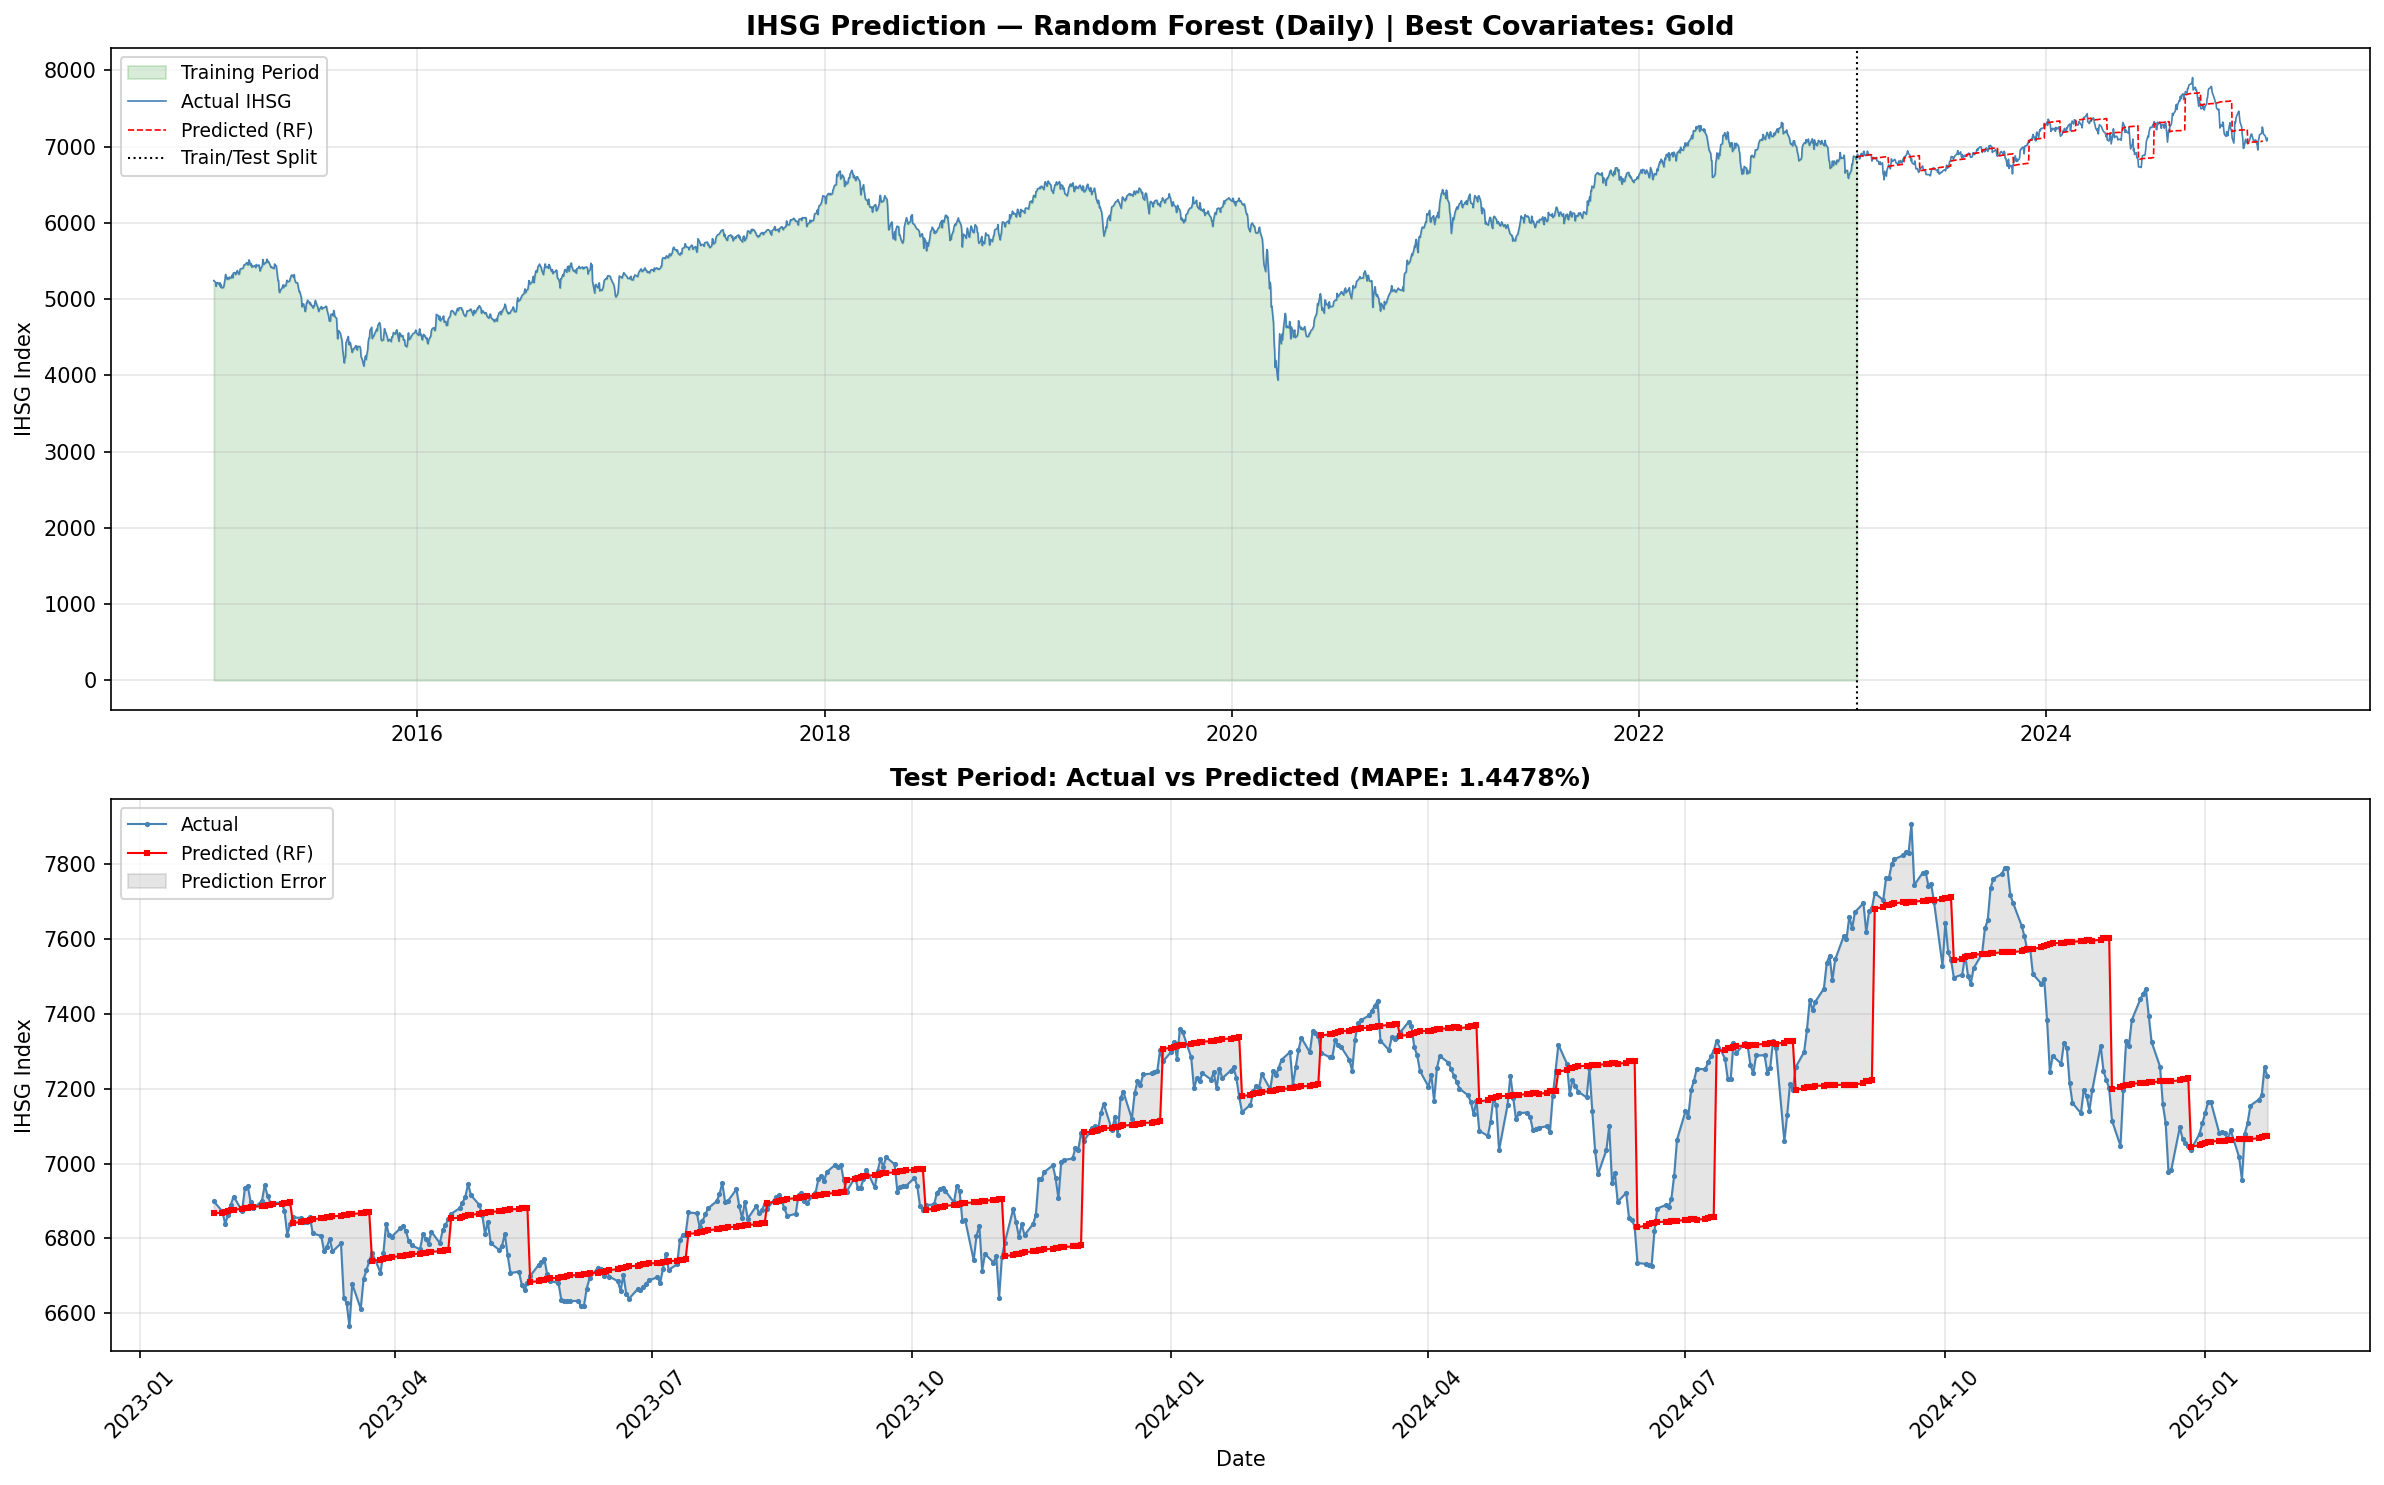

In [70]:
# ============================================================
# PLOT 1: FULL TIMELINE + ZOOMED TEST PERIOD
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [1.2, 1]})

train_data = best_df[best_df["train_flag"] == 1]
test_data = best_df[best_df["train_flag"] == 0]

# Top: Full timeline
ax1 = axes[0]
ax1.fill_between(train_data["date"], 0, train_data["actual"],
                 alpha=0.15, color="green", label="Training Period")
ax1.plot(best_df["date"], best_df["actual"], color="steelblue",
         linewidth=0.8, label="Actual IHSG")
ax1.plot(test_pred["date"], test_pred["predicted"], color="red",
         linewidth=0.8, linestyle="--", label="Predicted (RF)")
split_date = train_data["date"].max()
ax1.axvline(x=split_date, color="black", linestyle=":", linewidth=1, label="Train/Test Split")
ax1.set_title(f"IHSG Prediction — Random Forest (Daily) | Best Covariates: {best_row['Covariates']}",
              fontsize=13, fontweight="bold")
ax1.set_ylabel("IHSG Index")
ax1.legend(loc="upper left", fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Bottom: Zoomed test
ax2 = axes[1]
ax2.plot(test_pred["date"], test_pred["actual"], color="steelblue",
         linewidth=1, marker="o", markersize=1.5, label="Actual")
ax2.plot(test_pred["date"], test_pred["predicted"], color="red",
         linewidth=1, marker="s", markersize=1.5, label="Predicted (RF)")
ax2.fill_between(test_pred["date"], test_pred["actual"], test_pred["predicted"],
                 alpha=0.2, color="gray", label="Prediction Error")
ax2.set_title(f"Test Period: Actual vs Predicted (MAPE: {best_row['MAPE']}%)",
              fontsize=12, fontweight="bold")
ax2.set_xlabel("Date")
ax2.set_ylabel("IHSG Index")
ax2.legend(loc="upper left", fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("plot1_full_timeline.png", dpi=300, bbox_inches="tight")
plt.show()

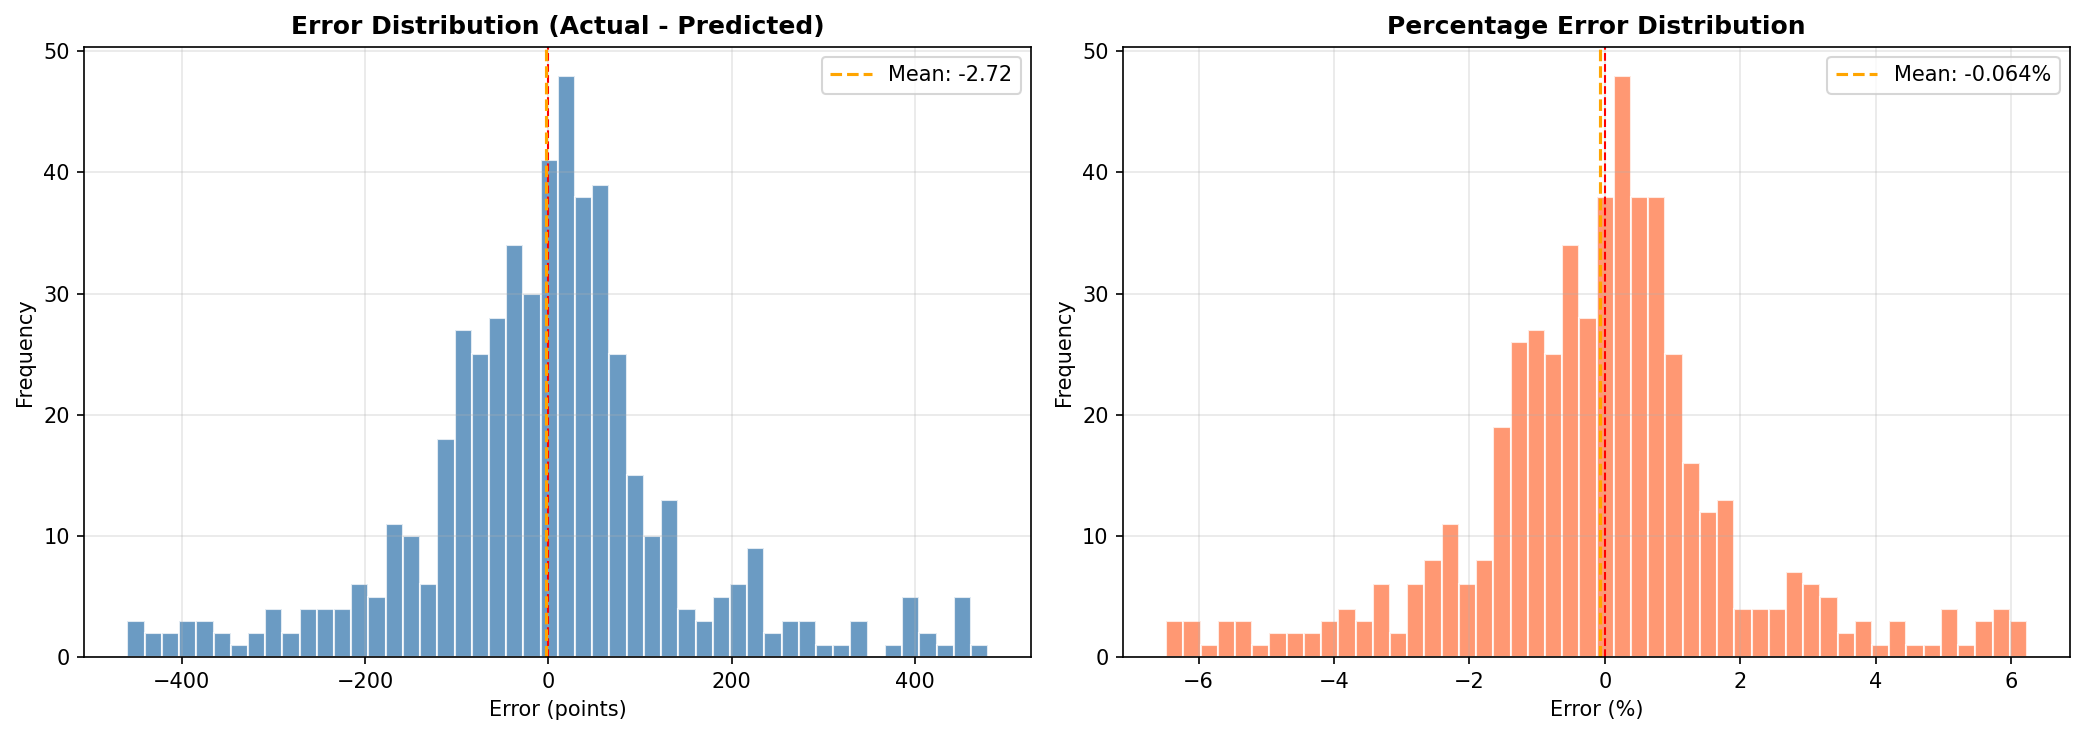

In [71]:
# ============================================================
# PLOT 2: ERROR DISTRIBUTION
# ============================================================

errors = test_pred["actual"] - test_pred["predicted"]
pct_errors = (errors / test_pred["actual"]) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(errors, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(x=0, color="red", linestyle="--", linewidth=1)
axes[0].axvline(x=errors.mean(), color="orange", linestyle="--",
                label=f"Mean: {errors.mean():.2f}")
axes[0].set_title("Error Distribution (Actual - Predicted)", fontweight="bold")
axes[0].set_xlabel("Error (points)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(pct_errors, bins=50, color="coral", edgecolor="white", alpha=0.8)
axes[1].axvline(x=0, color="red", linestyle="--", linewidth=1)
axes[1].axvline(x=pct_errors.mean(), color="orange", linestyle="--",
                label=f"Mean: {pct_errors.mean():.3f}%")
axes[1].set_title("Percentage Error Distribution", fontweight="bold")
axes[1].set_xlabel("Error (%)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("plot2_error_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

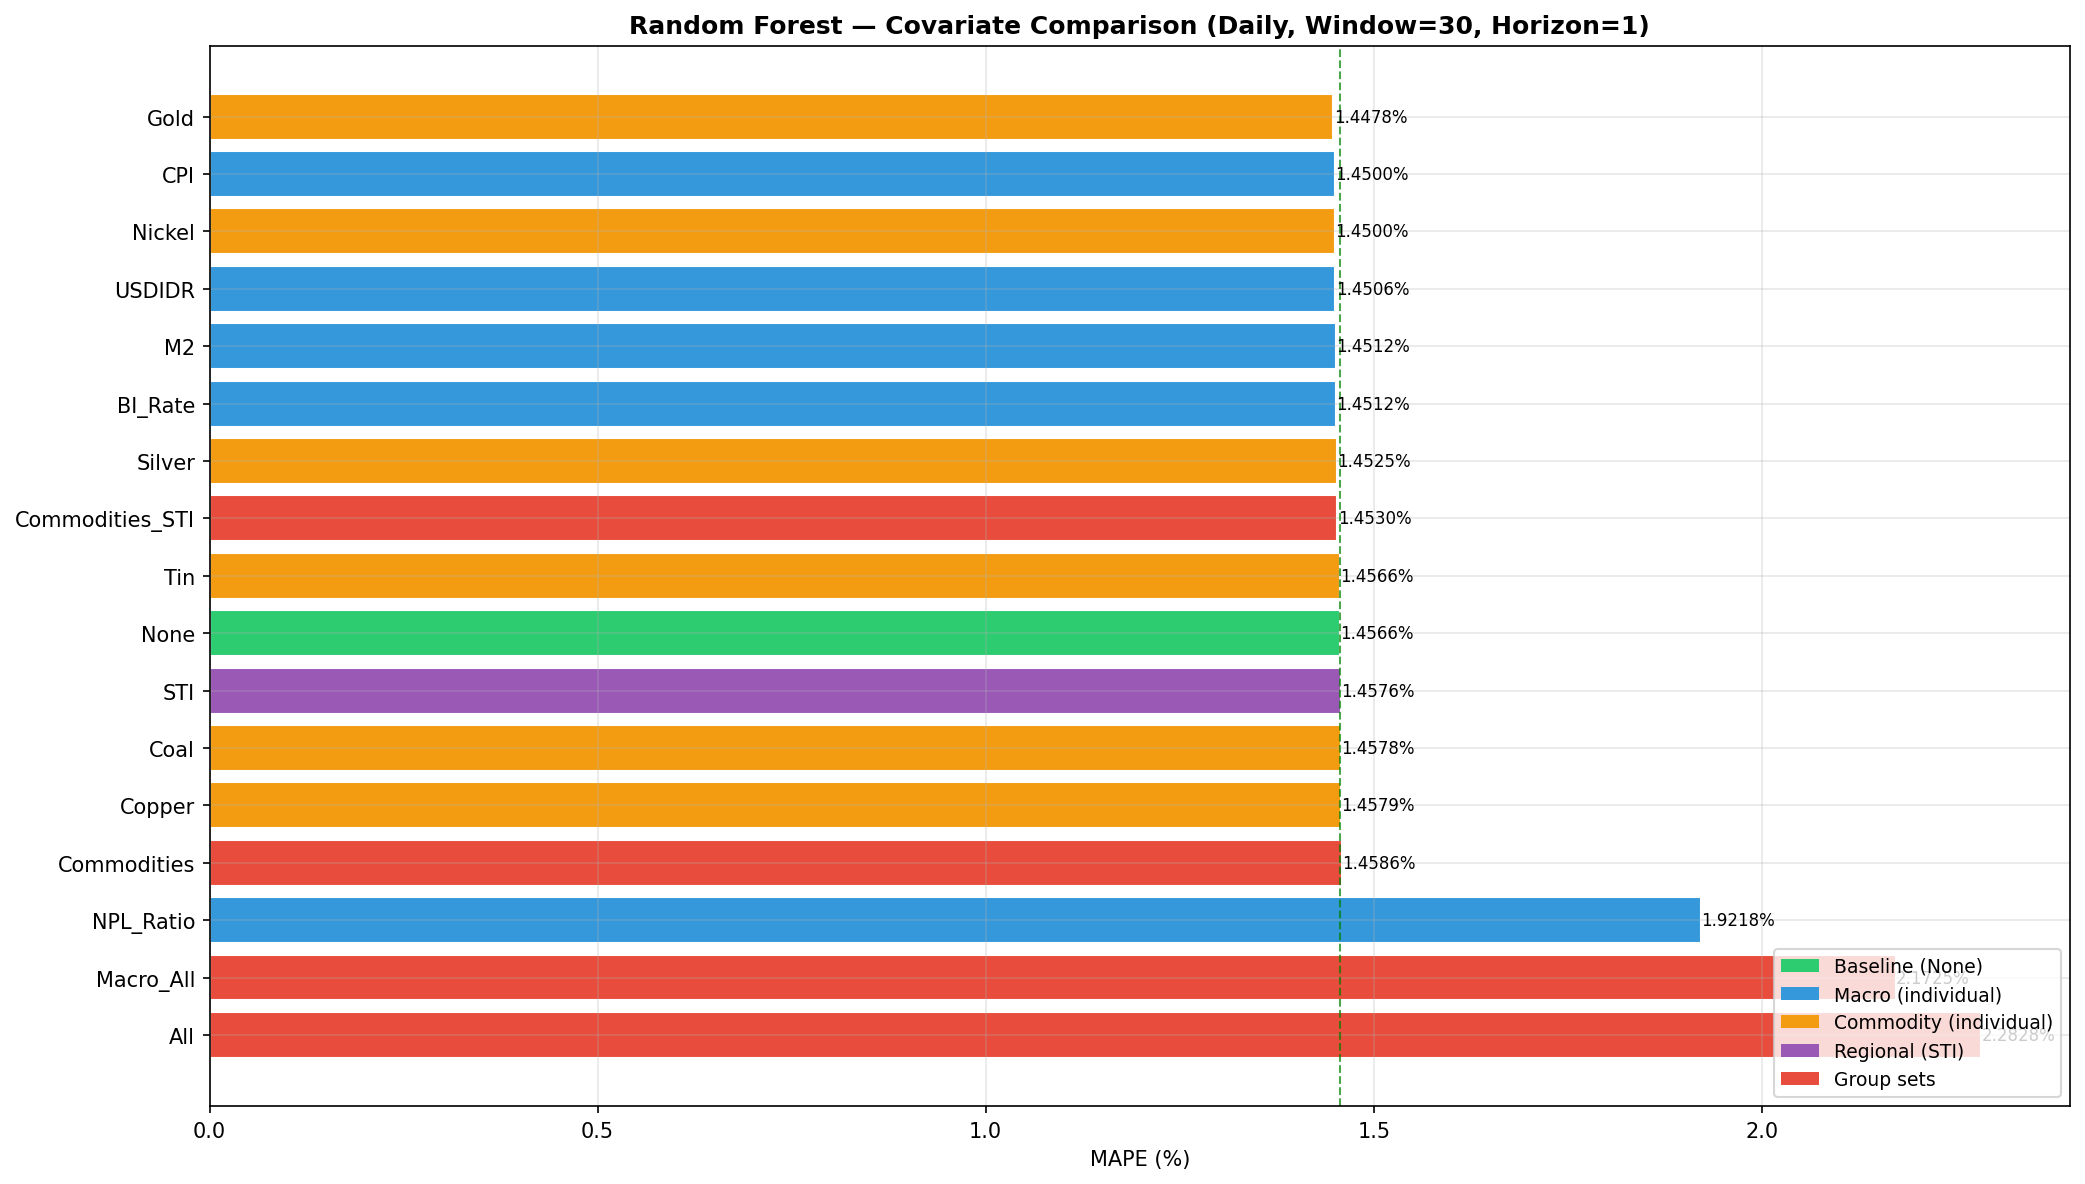

In [72]:
# ============================================================
# PLOT 3: COVARIATE COMPARISON BAR CHART
# ============================================================

comparison = valid_results[["Covariates", "Num_Vars", "MAPE", "MAE"]].sort_values("MAPE")

fig, ax = plt.subplots(figsize=(14, 8))

# Color coding by category
macro_vars = {"BI_Rate", "CPI", "M2", "NPL_Ratio", "USDIDR"}
commodity_vars = {"Coal", "Copper", "Nickel", "Silver", "Tin", "Gold"}
group_vars = {"All", "Macro_All", "Commodities", "Commodities_STI"}

colors = []
for cov in comparison["Covariates"]:
    if cov == "None":           colors.append("#2ecc71")  # green - baseline
    elif cov in group_vars:      colors.append("#e74c3c")  # red - groups
    elif cov in macro_vars:      colors.append("#3498db")  # blue - macro
    elif cov in commodity_vars:  colors.append("#f39c12")  # orange - commodity
    elif cov == "STI":          colors.append("#9b59b6")  # purple - regional
    else:                        colors.append("#95a5a6")  # gray

bars = ax.barh(comparison["Covariates"], comparison["MAPE"], color=colors, edgecolor="white")
for bar, mape_val in zip(bars, comparison["MAPE"]):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height() / 2,
            f"{mape_val:.4f}%", va="center", fontsize=8)

ax.axvline(x=baseline_mape, color="green", linestyle="--", linewidth=1,
           alpha=0.7, label=f"Baseline (None): {baseline_mape:.4f}%")

# Legend for categories
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="Baseline (None)"),
    Patch(facecolor="#3498db", label="Macro (individual)"),
    Patch(facecolor="#f39c12", label="Commodity (individual)"),
    Patch(facecolor="#9b59b6", label="Regional (STI)"),
    Patch(facecolor="#e74c3c", label="Group sets"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

ax.set_xlabel("MAPE (%)")
ax.set_title("Random Forest — Covariate Comparison (Daily, Window=30, Horizon=1)",
             fontsize=12, fontweight="bold")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("plot3_covariate_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

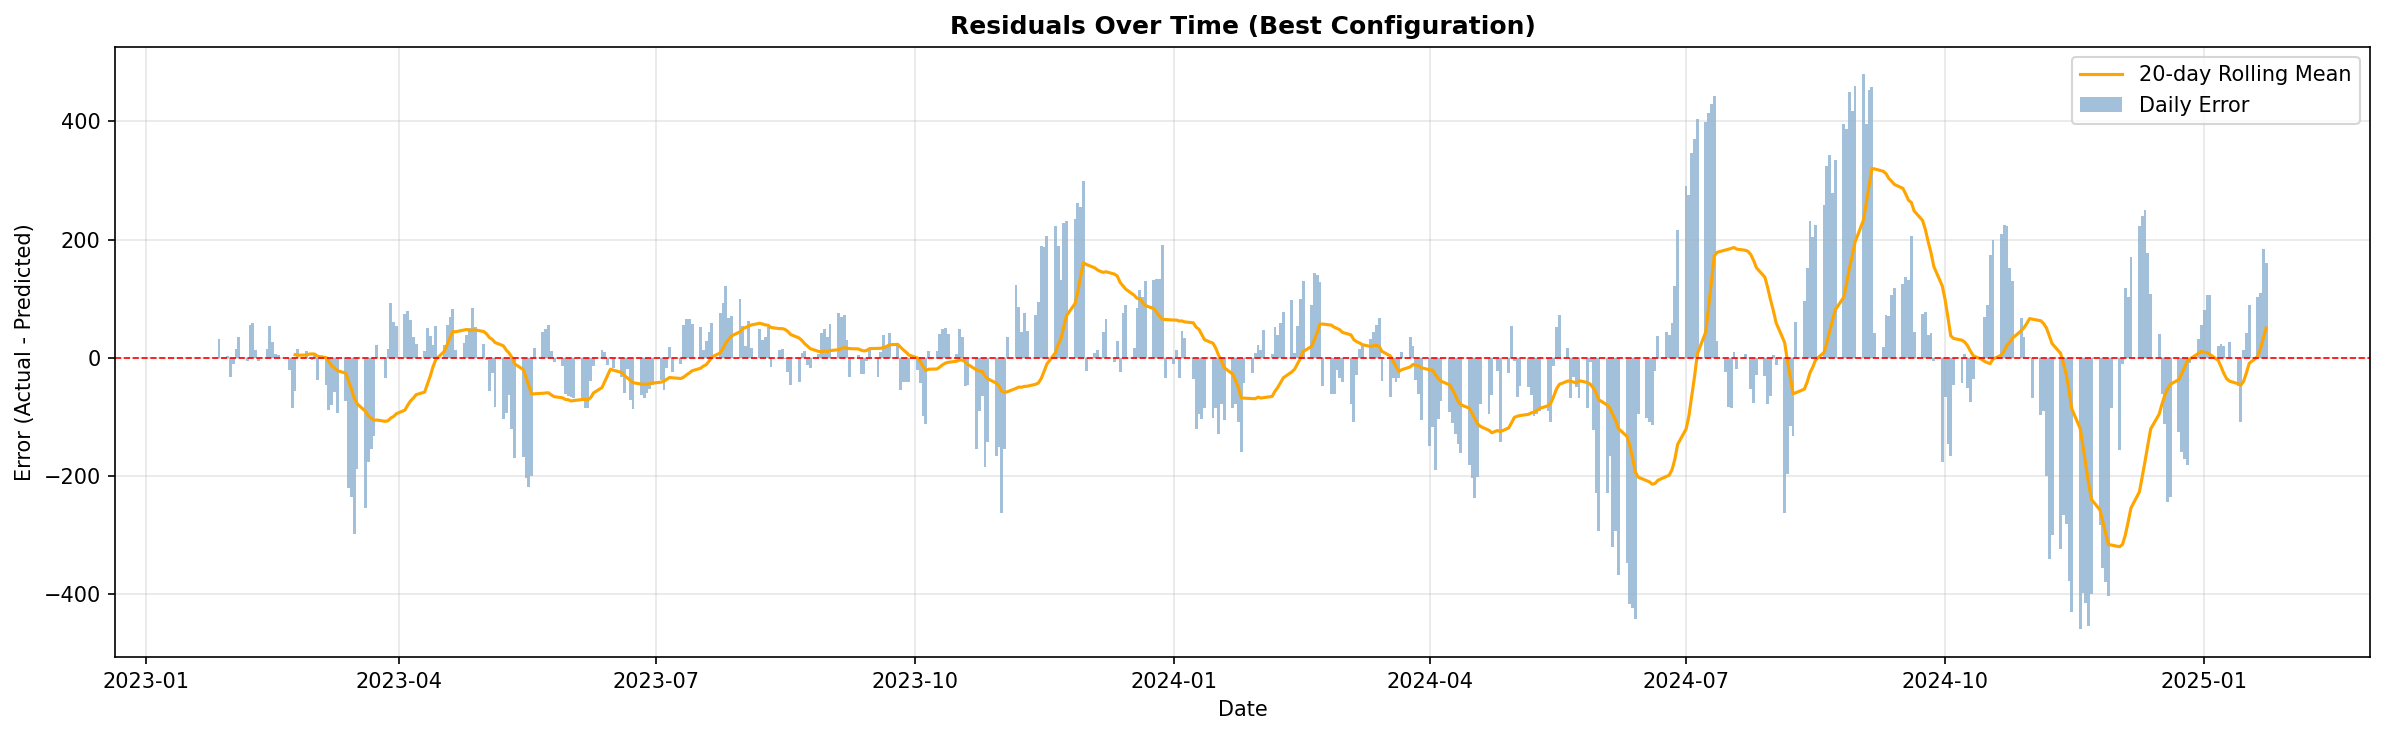

In [73]:
# ============================================================
# PLOT 4: RESIDUALS OVER TIME
# ============================================================

fig, ax = plt.subplots(figsize=(16, 5))

errors = test_pred["actual"] - test_pred["predicted"]
ax.bar(test_pred["date"], errors, width=1, alpha=0.5, color="steelblue", label="Daily Error")

rolling_mean = errors.rolling(20).mean()
ax.plot(test_pred["date"], rolling_mean, color="orange", linewidth=1.5,
        label="20-day Rolling Mean")
ax.axhline(y=0, color="red", linestyle="--", linewidth=0.8)

ax.set_title("Residuals Over Time (Best Configuration)", fontsize=12, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Error (Actual - Predicted)")
ax.legend()

plt.tight_layout()
plt.savefig("plot4_residuals.png", dpi=300, bbox_inches="tight")
plt.show()

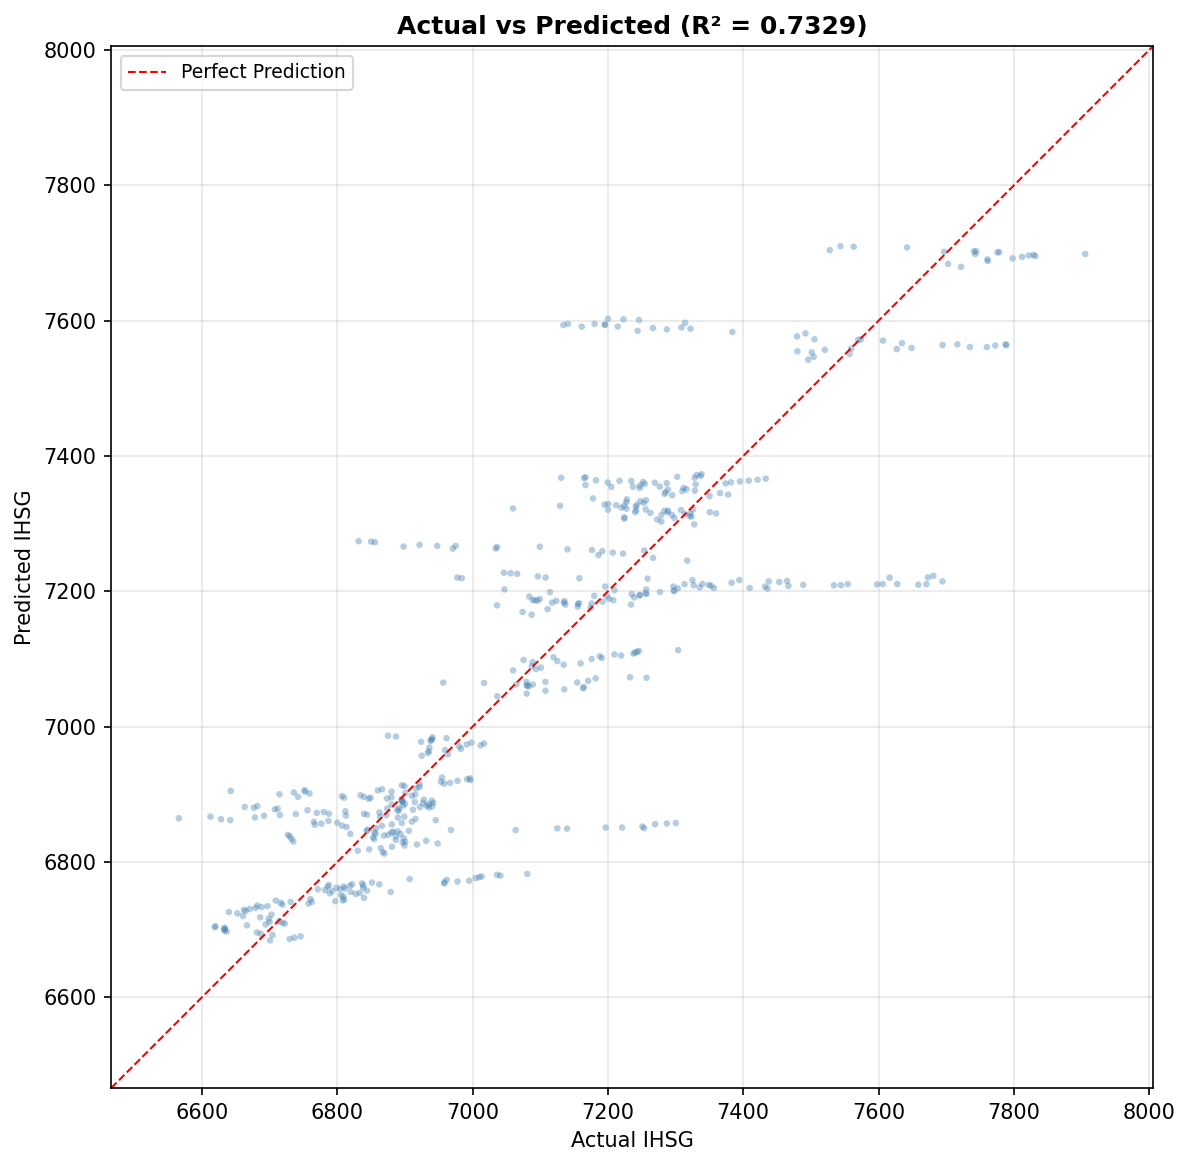

R² = 0.7329


In [74]:
# ============================================================
# PLOT 5: SCATTER ACTUAL vs PREDICTED + R²
# ============================================================

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(test_pred["actual"], test_pred["predicted"],
           alpha=0.4, s=10, color="steelblue", edgecolors="none")

min_val = min(test_pred["actual"].min(), test_pred["predicted"].min()) - 100
max_val = max(test_pred["actual"].max(), test_pred["predicted"].max()) + 100
ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1, label="Perfect Prediction")

ss_res = np.sum((test_pred["actual"] - test_pred["predicted"]) ** 2)
ss_tot = np.sum((test_pred["actual"] - test_pred["actual"].mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)

ax.set_title(f"Actual vs Predicted (R² = {r2:.4f})", fontsize=12, fontweight="bold")
ax.set_xlabel("Actual IHSG")
ax.set_ylabel("Predicted IHSG")
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.set_aspect("equal")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("plot5_scatter.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"R² = {r2:.4f}")

## 7. Summary

In [16]:
print("=" * 75)
print("MODEL 1 (DAILY) RESULTS SUMMARY — RANDOM FOREST")
print("=" * 75)
print(f"Target          : IHSG (Daily Frequency)")
print(f"Covariates      : Macro + Commodities + STI")
print(f"Scenario        : Short-Term Sprint (window=30, horizon=1)")
print(f"Prediction Type : One-Step Ahead (rolling)")
print(f"Algorithm       : Random Forest")
print(f"Date Range      : {df_merged['date'].min().date()} to {df_merged['date'].max().date()}")
print(f"Total Obs       : {len(df_merged)} business days")
print(f"Train/Test      : 80/20 split")

print(f"\n{'Covariates':<18} | {'#Vars':>5} | {'MAPE':>8} | {'MAE':>10} | {'MSE':>14} | vs Baseline")
print(f"{'-'*80}")

for _, row in valid_results.sort_values("MAPE").iterrows():
    diff = ((row["MAPE"] - baseline_mape) / baseline_mape) * 100
    marker = " <-- BEST" if row["MAPE"] == valid_results["MAPE"].min() else ""
    print(f"{row['Covariates']:<18} | {int(row.get('Num_Vars', 0)):>5} | {row['MAPE']:>7.4f}% | {row['MAE']:>10.2f} | {row['MSE']:>14.2f} | {diff:>+7.3f}%{marker}")

print(f"\n{'='*75}")
print(f"Note: MAPE ~0.5% is expected for one-step daily prediction.")
print(f"Dominated by autoregressive patterns (IHSG lags).")

MODEL 1 (DAILY) RESULTS SUMMARY — RANDOM FOREST
Target          : IHSG (Daily Frequency)
Covariates      : Macro + Commodities + STI
Scenario        : Short-Term Sprint (window=30, horizon=1)
Prediction Type : One-Step Ahead (rolling)
Algorithm       : Random Forest
Date Range      : 2015-01-02 to 2025-01-31
Total Obs       : 2443 business days
Train/Test      : 80/20 split

Covariates         | #Vars |     MAPE |        MAE |            MSE | vs Baseline
--------------------------------------------------------------------------------
STI                |     1 |  0.5049% |      35.91 |        2312.65 |  -0.473% <-- BEST
Tin                |     1 |  0.5069% |      36.04 |        2317.63 |  -0.079%
Nickel             |     1 |  0.5070% |      36.05 |        2316.75 |  -0.059%
NPL_Ratio          |     1 |  0.5071% |      36.05 |        2319.10 |  -0.039%
Coal               |     1 |  0.5072% |      36.06 |        2321.22 |  -0.020%
BI_Rate            |     1 |  0.5072% |      36.06 |   

In [17]:
# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
results_df.to_csv(f"rf_model1_daily_results_{timestamp}.csv", index=False)
print(f"Saved: rf_model1_daily_results_{timestamp}.csv")

Saved: rf_model1_daily_results_20260224_1337.csv
